## Regression

this dataset was imported from this link
 https://www.kaggle.com/datasets/CooperUnion/cardataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


### 1- Data Preparation

In [2]:
df= pd.read_csv('data.csv')
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
## standardizing the column names
df.columns=df.columns.str.lower().str.replace(" ","_")
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [4]:
## selecting string columns to transform them

strings=list(df.dtypes[df.dtypes=='str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [5]:
## transforming values
for col in strings:
    df[col]=df[col].str.lower().str.replace(" ","_")
df['model']

0        1_series_m
1          1_series
2          1_series
3          1_series
4          1_series
            ...    
11909           zdx
11910           zdx
11911           zdx
11912           zdx
11913        zephyr
Name: model, Length: 11914, dtype: str

In [6]:
##EDA

for col in df.columns:
    print(col)
    print(df[col].unique()[:5])## first 5 unique values only
    print(df[col].nunique()) ## overall unique values
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

<Axes: xlabel='msrp', ylabel='Count'>

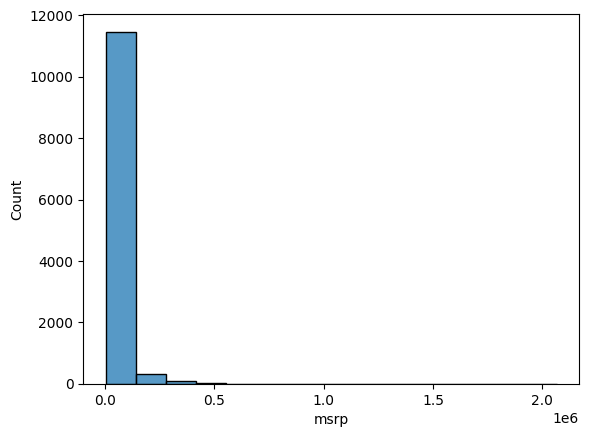

In [7]:
### Visualization
%matplotlib inline

sns.histplot(df['msrp'],bins=15)

<Axes: xlabel='msrp', ylabel='Count'>

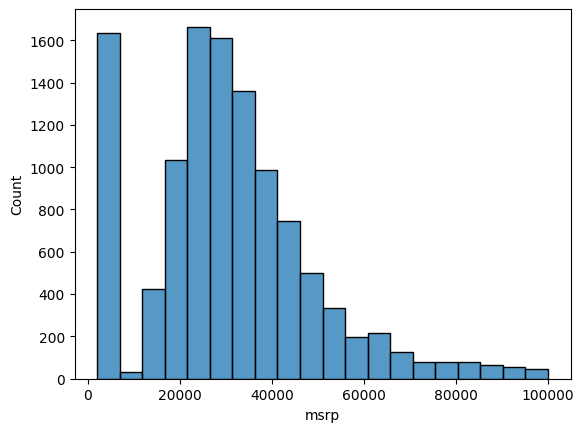

In [8]:
## above graph is a long tail distribution

sns.histplot(df.msrp[df.msrp<100000],bins=20)

In [9]:
## to handle the tail we will use np log method ,it is used to compute natural log base of input()

print(np.log([0,1,10,1000,100000]))
print(np.log([0+1,1+1,10+1,1000+1,100000]))

print(np.log1p([0,1,10,1000,100000])) ## this adds 1 becasuse log cannot hanlde 0 

[       -inf  0.          2.30258509  6.90775528 11.51292546]
[ 0.          0.69314718  2.39789527  6.90875478 11.51292546]
[ 0.          0.69314718  2.39789527  6.90875478 11.51293546]


/tmp/ipykernel_2838/3265347789.py:3: RuntimeWarning: divide by zero encountered in log
  print(np.log([0,1,10,1000,100000]))


In [10]:
price_logs=np.log1p(df.msrp)

print(price_logs)

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64


<Axes: xlabel='msrp', ylabel='Count'>

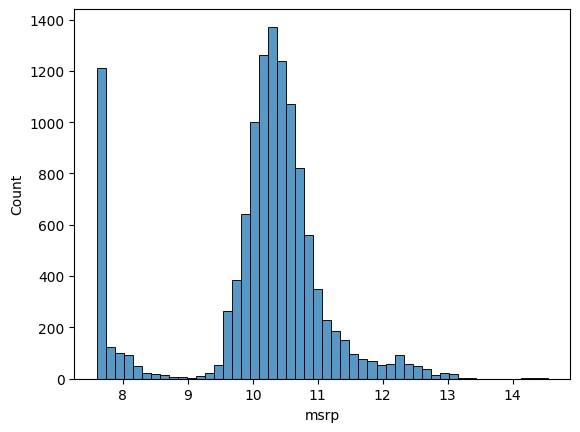

In [11]:
sns.histplot(price_logs,bins=50) ## the tail is gone better for ML model normal distribution

In [12]:
## missing values

df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### 02 Validation Framework

In [13]:
### Data needs to be divided into Train ,test and Validation sets

len(df)
n=len(df)
n_val=int(n*0.20) ## 20% validation
n_test=int(n*0.20) ### 20% test
n_train= n-n_val-n_test ## 60% (remaining for train)

print(n,(n_test+n_val+n_train)) ## we used int above to get exact records not fractions


11914 11914


In [14]:
## segregating datasets using iloc method

df_val=df.iloc[:n_val]
df_test=df.iloc[n_val:n_val+n_test]
df_train=df.iloc[n_val+n_test:]

df_train ## there is a problem with this data there is an order means all bws are in validation we need mix so
## we will reshuffle the dataset

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4764,ford,flex,2016,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,37800
4765,ford,flex,2017,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,crossover,large,wagon,21,15,5657,43030
4766,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",large,wagon,22,16,5657,40180
4767,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,32730
4768,ford,flex,2017,regular_unleaded,287.0,6.0,automatic,front_wheel_drive,4.0,"crossover,performance",large,wagon,23,16,5657,38230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [15]:
## randomly generating an array to shuffle dataframe

idx=np.arange(n)
idx
## shufffling the array
np.random.seed(2)
np.random.shuffle(idx)
df_shuffled = df.iloc[idx]

In [16]:
## will use this array to divide data into train test and validation
df_train=df_shuffled.iloc[:n_train].copy()
df_val=df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test=df_shuffled.iloc[n_train+n_val:].copy()

In [17]:
len(df_train),len(df_val),len(df_test),len(df)


(7150, 2382, 2382, 11914)

In [18]:
##getting base log of price
y_train_orig = df_train.msrp.values
y_val_orig = df_val.msrp.values
y_test_orig = df_test.msrp.values

y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)
## now deleting msrp variable
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']


## Linear Regression

Its an ML model used to predict numbers/numeric values
g(x)~~y
where g is our model ,x is feature matrix and y is the outcome/target variable
> y is price and g is linear regression

The formula for regression is 
 g(xi)=W0+ w1Xi1+W2Xi2+W3Xi3....WnXiN 
 Where W0 is bias and W1,W2... are weights and x is list of features 
 we can then write this in this form

 g(Xi)=W0+Sum(Wj+Xij)

In [19]:
## lets take one car/1 row as an sample for model development

df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 7557, dtype: object

In [20]:


##selecting features of engine_hp,city_mpg & popularity so
xi=[453,11,86]
w0=7.17
w=[0.01,0.04,0.002]

def linear_regression(xi):
    n=len(xi)
    prediction=w0
    for j in range(n):
      prediction= prediction+w[j]*xi[j]
    return prediction 

In [21]:

linear_regression(xi)

12.312

In [22]:
## we changed prices to base log we will convert the predicted price to actual one

np.exp(12.321)-1

np.float64(224357.38828829568)

## Linear regression vector form

In [23]:
def dot(xi,w):
    n=len(xi)
    result=0.0
    for j in range(n):
        result=result+ w[j] * xi[j]
    return result

In [24]:
def linear_regression(xi):
    return w0+ dot(xi,w)

linear_regression(xi)

12.312000000000001

In [25]:
#### lets take few more samples and change strategy it can be done by using dot product of Numpy rather than using for loop

x1=[1,148,24,1385]
x2=[1,132,25,2031]
x10=[1,453,11,86]

X=[x1,x2,x10]
X=np.array(X)

w0=7.17
w=[0.01,0.04,0.002]
w_new =[w0]+w


X.dot(w_new)

array([12.38 , 13.552, 12.312])

In [26]:
def linear_regression(X):
      return X.dot(w_new)

linear_regression(X)

array([12.38 , 13.552, 12.312])

### training ML model


In [27]:
##random lists to find weights
X=[[ 148,   24, 1385],
[    145,   25, 2031],
[   453,   11,   86],
[     178,   24, 1385],
[    132,   25, 2031],
[   453,   11,   86],
[     457,   24, 1385],
[    675,   25, 2031],
[   333,   11,   86]]

X=np.array(X)
X

array([[ 148,   24, 1385],
       [ 145,   25, 2031],
       [ 453,   11,   86],
       [ 178,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 457,   24, 1385],
       [ 675,   25, 2031],
       [ 333,   11,   86]])

In [28]:
## adding bias terms
## add to rows of X
#ones=np.ones(X.shape[0])

#X=np.column_stack([ones,X])
#X


In [29]:
## randomnumbers
y=[100000,20000,30000,40000,500000,600000,10000,20000,30000]

In [30]:
## Transpose of x
#XTX=X.T.dot(X)
#XTX_inv=np.linalg.inv(XTX)
#XTX_inv

In [31]:
#w_full=XTX_inv.dot(X.T).dot(y)
#w_full

In [32]:
#w0=w_full[0]
#w=w_full[1:]

In [33]:
 

def training_linear_regression(X,y):
     ones = np.ones(X.shape[0])
     X = np.column_stack([ones, X])

     XTX = X.T.dot(X)
     XTX_inv = np.linalg.inv(XTX)
     w = XTX_inv.dot(X.T).dot(y)
    
     return w[0], w[1:]



In [34]:
training_linear_regression(X,y)

(np.float64(832030.6876017622),
 array([  -303.56638509, -46585.69768221,    299.82446446]))

## Baseline model


In [35]:
df.dtypes

base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']



In [36]:
## imputing nulls with 0

#df_train[base].isnull().sum()
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [37]:
## Set of features
X_train = prepare_X(df_train)
w_0, w = training_linear_regression(X_train, y_train)

In [38]:
## train LRM

y_pred = w_0 + X_train.dot(w)

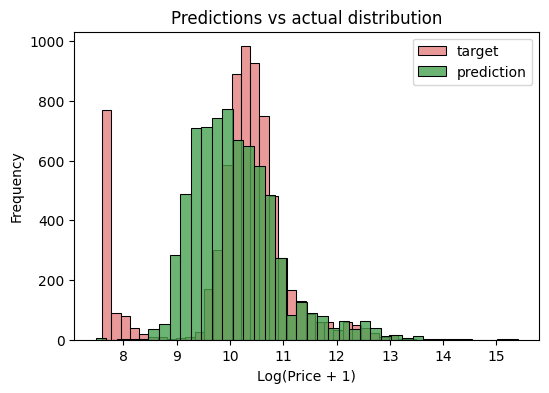

In [39]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color="#DC5656", alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color="#47a250", alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

##### RSME


In [40]:
## Implementing RSME

def rsme(y,y_pred):
    error=(y-y_pred)**2
    mse=error.mean()
    return np.sqrt(mse)

In [41]:
rsme(y_train,y_pred)



np.float64(0.7554192603920132)

### Validating Model

In [42]:
## training prt
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)

#validationpart
rsme(y_val, y_pred)

np.float64(0.7616530991301604)

### Simple feature engineering

In [43]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [44]:
X_train = prepare_X(df_train)
w_0, w = training_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rsme(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rsme(y_val, y_pred))

train 0.5175055465840046
validation 0.517205546105833


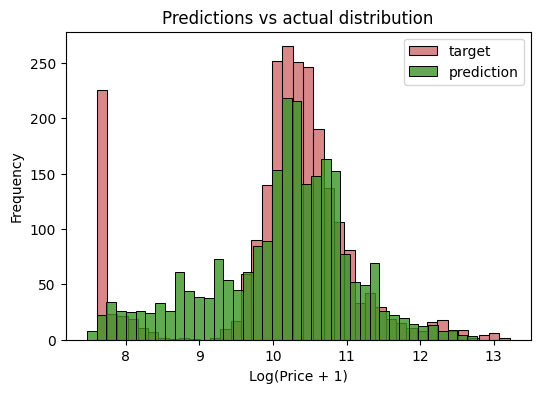

In [45]:
plt.figure(figsize=(6, 4))


sns.histplot(y_val, label='target', color="#BE3939", alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color="#3b9525", alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

### Categorical variables


In [46]:
for v in [2,3,4]:
  df_train['num_of_door_%s' %v]= (df_train['number_of_doors']==v).astype(int)

df_train.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_of_door_2,num_of_door_3,num_of_door_4
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1


In [47]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
     df['num_of_door_%s' %v]= (df['number_of_doors']==v).astype(int)
    features.append('num_of_door_%s' %v)


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [48]:
prepare_X(df_train)

array([[1.480e+02, 4.000e+00, 3.300e+01, ..., 1.385e+03, 9.000e+00,
        0.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, ..., 2.031e+03, 5.000e+00,
        1.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, ..., 6.400e+02, 1.000e+00,
        1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 2.200e+01, ..., 5.490e+02, 2.000e+00,
        1.000e+00],
       [5.630e+02, 1.200e+01, 2.100e+01, ..., 8.600e+01, 3.000e+00,
        1.000e+00],
       [2.000e+02, 4.000e+00, 3.100e+01, ..., 8.730e+02, 0.000e+00,
        1.000e+00]], shape=(7150, 7))

In [49]:
X_train = prepare_X(df_train)
w_0, w = training_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rsme(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rsme(y_val, y_pred))

train 0.5173930994177068
validation 0.5170419578831623


In [50]:
makes=list(df.make.value_counts().head().index)

In [51]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
     df['num_of_door_%s' %v]= (df['number_of_doors']==v).astype(int)
     features.append('num_of_door_%s' %v)
    
    for make in makes:
     df['makes_%s' %make]= (df['make']==make).astype(int)
     features.append('makes_%s' %make)


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [52]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   0.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   1.,   0.],
       [148.,   4.,  37., ...,   0.,   0.,   0.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   0.],
       [563.,  12.,  21., ...,   0.,   0.,   0.],
       [200.,   4.,  31., ...,   1.,   0.,   0.]], shape=(7150, 14))

In [53]:
X_train = prepare_X(df_train)
w_0, w = training_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rsme(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rsme(y_val, y_pred))

train 0.5058876515487503
validation 0.5076038849554877


### Regularization

In [54]:
## a hyperparameter that controls the trade-off between fitting training data well
#  and keeping model weights small to prevent overfitting
## adding a random number to diagnoal to improve performance of model
def training_linear_regression_r(X,y,r=0.001):
     ones = np.ones(X.shape[0])
     X = np.column_stack([ones, X])

     XTX = X.T.dot(X)
     XTX = XTX+r* np.eye(XTX. shape[0])
     XTX_inv = np.linalg.inv(XTX)
     w = XTX_inv.dot(X.T).dot(y)
    
     return w[0], w[1:]

In [55]:
X_train = prepare_X(df_train)
w_0, w = training_linear_regression_r(X_train, y_train,r=0.01)

y_pred = w_0 + X_train.dot(w)
print('train', rsme(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rsme(y_val, y_pred))

train 0.5058882073752605
validation 0.5076120374936173


### USING Model

In [60]:
df_full_train=pd.concat([df_train,df_val])

df_full_train=df_full_train.reset_index(drop=True)

X_full_train=prepare_X(df_full_train)
X_full_train

array([[148.,   4.,  33., ...,   0.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   1.,   0.],
       [148.,   4.,  37., ...,   0.,   0.,   0.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 14))

In [62]:
y_full_train=np.concatenate([y_train,y_val])

w_0, w = training_linear_regression_r(X_full_train, y_full_train,r=0.001)

In [63]:
#preparing test dataset

X_test = prepare_X(df_test)
y_pred = w_0 + X_test.dot(w)
print('validation', rsme(y_test, y_pred))

validation 0.5051000635649082


In [66]:
##testing on car mode

car=df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [81]:

df_small=pd.DataFrame([car])

x_car=prepare_X(df_small)

y_pred = w_0 + x_car.dot(w)
y_pred=y_pred[0]
y_pred

## this log price so converting to actual price
predict_price=np.expm1(y_pred)
print("predicted:",predict_price)
## predicted price is 32501 

y_test[20]

actual_price=np.expm1(y_test[20])
print("actual:",actual_price)


##It is a good prediction

predicted: 32501.865985229444
actual: 35000.00000000001
